In [1]:
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt

In [7]:
# Simple Character-level RNN (Hello sequence)
# 입력 시퀀스 (5글자)
# ↓
# LSTM (return_sequences=True → 5개 timestep 모두 반환)
# ↓
# TimeDistributed(Dense → 각 timestep에 softmax)
# ↓
# 각 timestep에 대해 “다음 문자 확률” 계산

random.seed(777)
np.random.seed(777)
tf.random.set_seed(777)

# Character mapping
idx2char = ['h', 'i', 'e', 'l', 'o']
# Teach hello: hihell -> ihello
x_data = [[0, 1, 0, 2, 3, 3]]  # hihell
y_data = [[1, 0, 2, 3, 3, 4]]  # ihello

num_classes = 5
input_dim = 5  # one-hot size
sequence_length = 6
learning_rate = 0.1

# One-hot encoding
x_one_hot = tf.keras.utils.to_categorical(x_data, num_classes=num_classes)
y_one_hot = tf.keras.utils.to_categorical(y_data, num_classes=num_classes)

# Model
# LSTM(units=num_classes) -> units: 문자개수(LSTM이 마지막에 만들어내는 벡터 크기)
# return_sequences=True -> 모든 타임스텝의 hidden state를 다음 층에 전달하도록 함
# TimeDistributed(Dense()) -> 시퀀스 전체의 timestep에 대해 Dense를 각각 적용하는 wrapper
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=num_classes, input_shape=(sequence_length, input_dim), return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(units=num_classes, activation='softmax'))
])

model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              metrics=['accuracy'])

model.summary()
model.fit(x_one_hot, y_one_hot, epochs=50, verbose=0)

# Prediction
predictions = model.predict(x_one_hot)
for i, prediction in enumerate(predictions):
    result_str = [idx2char[c] for c in np.argmax(prediction, axis=1)]
    print(f"Prediction str: {''.join(result_str)}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 6, 5)                │             220 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 6, 5)                │              30 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 250 (1000.00 B)

 Trainable params: 250 (1000.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
Prediction str: ihello


In [8]:
# Character-level RNN (Custom sample)

sample = " if you want you"
idx2char = list(set(sample))  # index -> char
char2idx = {c: i for i, c in enumerate(idx2char)}  # char -> index

# Hyperparameters
dic_size = len(char2idx)
hidden_size = dic_size
num_classes = dic_size
batch_size = 1
sequence_length = len(sample) - 1
learning_rate = 0.1

# Data preprocessing
sample_idx = [char2idx[c] for c in sample]
x_data = [sample_idx[:-1]]
y_data = [sample_idx[1:]]

x_one_hot = tf.keras.utils.to_categorical(x_data, num_classes=num_classes)
y_one_hot = tf.keras.utils.to_categorical(y_data, num_classes=num_classes)

# Model - LSTM Layer + TimeDistributed Layer
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=num_classes, input_shape=(sequence_length, num_classes), return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(units=num_classes, activation='softmax'))
])

model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              metrics=['accuracy'])

model.summary()
model.fit(x_one_hot, y_one_hot, epochs=50, verbose=0)

# Prediction
predictions = model.predict(x_one_hot)
for i, prediction in enumerate(predictions):
    result_str = [idx2char[c] for c in np.argmax(prediction, axis=1)]
    print(f"Prediction str: {''.join(result_str)}")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 15, 10)              │             840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, 15, 10)              │             110 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 950 (3.71 KB)

 Trainable params: 950 (3.71 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
Prediction str: if you want you


In [9]:
# Long char RNN (Custom sample)

# Reproducibility
random.seed(777)
np.random.seed(777)
tf.random.set_seed(777)

sentence = ("if you want to build a ship, don't drum up people together to "
            "collect wood and don't assign them tasks and work, but rather "
            "teach them to long for the endless immensity of the sea.")

char_set = list(set(sentence))
char_dic = {w: i for i, w in enumerate(char_set)}

data_dim = len(char_set)
hidden_size = len(char_set)
num_classes = len(char_set)
sequence_length = 10
learning_rate = 0.1

dataX = []
dataY = []
# Sliding Window 방식으로 학습 데이터 구성
    # 각 timestep에 대해 “다음 글자”를 예측하도록 설정
for i in range(len(sentence) - sequence_length):
    x_str = sentence[i:i + sequence_length]
    y_str = sentence[i + 1:i + sequence_length + 1]

    x = [char_dic[c] for c in x_str]
    y = [char_dic[c] for c in y_str]

    dataX.append(x)
    dataY.append(y)

batch_size = len(dataX)

# One-hot encoding
X_one_hot = tf.keras.utils.to_categorical(dataX, num_classes)
Y_one_hot = tf.keras.utils.to_categorical(dataY, num_classes)

print("X shape:", X_one_hot.shape)  # (samples, sequence_length, num_classes)
print("Y shape:", Y_one_hot.shape)

# Model: 2Layer LSTM + TimeDistributed Layer
    # sequence_length = 10; "10글자를 보고 다음 글자" 예측
    # 모든 가능한 10글자 subsequence를 학습
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=num_classes, input_shape=(sequence_length, X_one_hot.shape[2]), return_sequences=True),
    tf.keras.layers.LSTM(units=num_classes, return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(units=num_classes, activation='softmax'))
])

model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              metrics=['accuracy'])

model.summary()
model.fit(X_one_hot, Y_one_hot, epochs=100, batch_size=batch_size, verbose=0)

# Prediction
results = model.predict(X_one_hot)
for j, result in enumerate(results):
    index = np.argmax(result, axis=1)
    if j == 0:
        # 첫 샘플 전체 출력
        print(''.join([char_set[t] for t in index]), end='')
    else:
        # 나머지는 마지막 글자만 추가
        print(char_set[index[-1]], end='')


X shape: (170, 10, 25)
Y shape: (170, 10, 25)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 10, 25)              │           5,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 10, 25)              │           5,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_5 (TimeDistributed) │ (None, 10, 25)              │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,850 (42.38 KB)

 Trainable params: 10,850 (42.38 KB)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
t you wans to build a ship, don't drum up people together to collect wood and don't assign them tasks and work, but rather teach them to long for the endless immensity of the seac

TrainX: (505, 7, 5) TrainY: (505, 1)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                        │ (None, 10)                  │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 651 (2.54 KB)

 Trainable params: 651 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


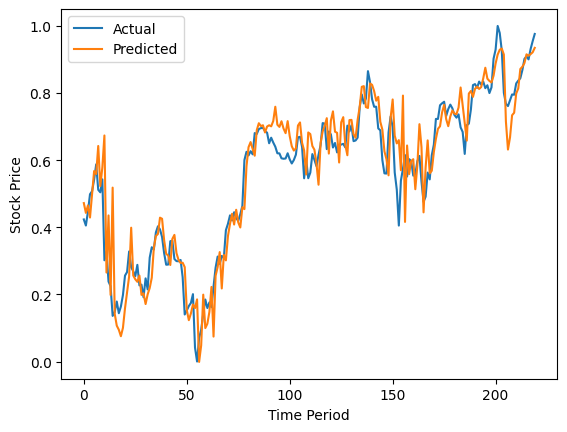

In [10]:
# Predict stock prices using a basic RNN

# Reproducibility
np.random.seed(777)
tf.random.set_seed(777)

# 정규화 -> 시계열 데이터의 값은 scale이 크기때문
def MinMaxScaler(data):
    """ Min Max Normalization """
    numerator = data - np.min(data, 0)
    denominator = np.max(data, 0) - np.min(data, 0)
    return numerator / (denominator + 1e-7)  # prevent division by zero

# Train Parameters
seq_length = 7
data_dim = 5
output_dim = 1
learning_rate = 0.01
iterations = 500

# Load stock data
xy = np.loadtxt('data-02-stock_daily.csv', delimiter=',')
xy = xy[::-1]  # reverse order to chronological

# Train/test split
train_size = int(len(xy) * 0.7)
train_set = xy[0:train_size]
test_set = xy[train_size - seq_length:]  # include last seq_length for past context

# Scale
train_set = MinMaxScaler(train_set)
test_set = MinMaxScaler(test_set)

# Build datasets
def build_dataset(time_series, seq_length):
    dataX = []
    dataY = []
    # Sliding Window: 7일 데이터를 보고 → 다음날 종가 예측.
    for i in range(len(time_series) - seq_length):
        x = time_series[i:i + seq_length, :]
        y = time_series[i + seq_length, [-1]]  # next close price
        dataX.append(x)
        dataY.append(y)
    return np.array(dataX), np.array(dataY)

trainX, trainY = build_dataset(train_set, seq_length)
testX, testY = build_dataset(test_set, seq_length)

print("TrainX:", trainX.shape, "TrainY:", trainY.shape)

# Build model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=10, input_shape=(seq_length, data_dim)),  # increased units for better learning
    tf.keras.layers.Dense(units=output_dim, activation='tanh')
])

model.compile(loss='mean_squared_error',
              optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

model.summary()

# Train
model.fit(trainX, trainY, epochs=iterations, batch_size=16, verbose=0)  # batch_size 추가

# Predict
test_predict = model.predict(testX)

# Plot predictions
plt.plot(testY, label='Actual')
plt.plot(test_predict, label='Predicted')
plt.xlabel("Time Period")
plt.ylabel("Stock Price")
plt.legend()
plt.show()
